# Algorytm Jarvisa

In [3]:
%run interface.ipynb
%run tests.ipynb

### Algorytm bez wizualizacji

In [4]:
def jarvis(data_set):
    if len(data_set) <= 2:
        return data_set
    base_point = min(data_set, key=lambda p: (p.y, p.x))
    hull = []
    current = base_point

    def counter_clockwise(o, a, b):
        result = (a.x - o.x) * (b.y - o.y) - (a.y - o.y) * (b.x - o.x)
        if result > 1e-12:
            return 1
        elif result < -1e-12:
            return -1
        else:
            return 0

    while True:
        hull.append(current)
        next_point = None

        for point in data_set:
            if point == current:
                continue
            if next_point is None:
                next_point = point
                continue

            orientation = counter_clockwise(current, next_point, point)

            if orientation < 0 or (orientation == 0 and (point.x - current.x) ** 2 + (point.y - current.y) ** 2 > (next_point.x - current.x) ** 2 + (next_point.y - current.y) ** 2):
                next_point = point

        if next_point == base_point:
            break
        current = next_point

    return hull

### Testy poprawności

In [5]:
run_test(jarvis)

Test 1:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0113s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 5:
	Czas: 0.0s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 5/5
Czas: 0.0113s


In [ ]:
run_time_tests(jarvis)

### Zadawanie zbioru punktów

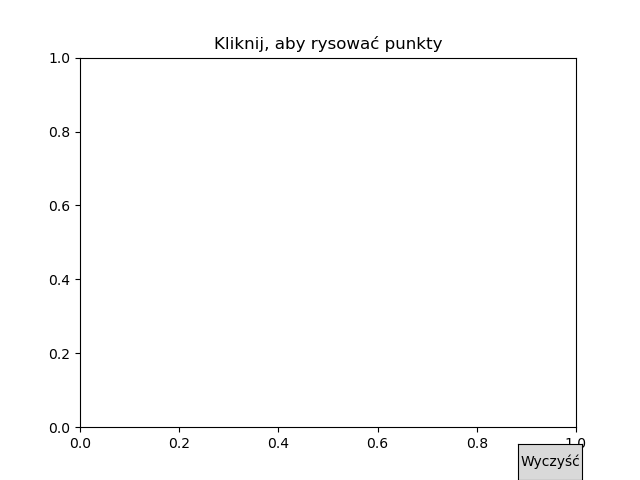

In [8]:
polygon = PolygonDrawer()

### Wizualizacja algorytmu

In [6]:
def jarvis_visual(data_set):
    visualizer = ConvexHullVisualizer()
    visualizer.speed = 100
    
    if len(data_set) <= 2:
        return data_set
    base_point = min(data_set, key=lambda p: (p.y, p.x))
    hull = []
    current = base_point

    def counter_clockwise(o, a, b):
        result = (a.x - o.x) * (b.y - o.y) - (a.y - o.y) * (b.x - o.x)
        if result > 1e-12:
            return 1
        elif result < -1e-12:
            return -1
        else:
            return 0

    while True:
        hull.append(current)
        next_point = None

        for point in data_set:
            if point == current:
                continue
            if next_point is None:
                next_point = point
                continue

            orientation = counter_clockwise(current, next_point, point)
            visualizer.add_frame(data_set, [], [hull], [], point)

            if orientation < 0 or (orientation == 0 and (point.x - current.x) ** 2 + (point.y - current.y) ** 2 > (next_point.x - current.x) ** 2 + (next_point.y - current.y) ** 2):
                next_point = point

        if next_point == base_point:
            break
        current = next_point
    
    visualizer.add_frame(data_set, [], [hull], [], current)
    visualizer.add_frame(data_set, [hull], [], [], None)

    display(visualizer.create_animation())

In [9]:
jarvis_visual(polygon.points)